## DataFrames

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
titanic = pd.read_csv('./dataset/titanic.csv')

## Aggregating Data

#### Summary statistics

### Summarizing numerical data
- .mean()
- .median()
- .min()
- .maxx()
- .var()
- .std()
- .sum()
- .quantile()

In [3]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [4]:
titanic['Age'].mode()

0    24.0
Name: Age, dtype: float64

In [5]:
titanic.Age.min()

np.float64(0.42)

In [6]:
titanic.Age.max()

np.float64(80.0)

In [7]:
titanic['Age'].var() #<--Return unbiased variance over requested axis.

np.float64(211.01912474630802)

In [8]:
titanic['Age'].quantile() #<--Return values at the given quantile over requested axis.

np.float64(28.0)

In [9]:
titanic['Age'].std()

np.float64(14.526497332334042)

In [10]:
titanic['Age'].sum()

np.float64(21205.17)

### summarizing dates

## .agg() method

- One or more operation on single Or multiple columns

In [11]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##### on Single column

In [12]:
def pct30(column):return column.quantile(0.3)

In [13]:
titanic['Age'].agg(pct30)#<-- applying agg() on a column using simple function

np.float64(22.0)

In [14]:
titanic['Age'].agg(lambda col : col.quantile(.3)) #<-- using lambda function

np.float64(22.0)

##### on multiple column

In [15]:
titanic[['Age', 'Fare']].agg(lambda x: x.quantile(0.3))

Age     22.00
Fare     8.05
dtype: float64

##### multiple summaries

In [16]:
#def pct30(column): return column.quantile(0.3)
def pct40(column): return column.quantile(0.4)

In [17]:
titanic['Age'].agg([pct30,pct40])

pct30    22.0
pct40    25.0
Name: Age, dtype: float64

### cumulative statistics
- .cumsum()
- .cummax()
- .cummin()
- .cumprod()

In [18]:
pd.DataFrame(titanic['Age'].cumsum()).head(4)

,Age
0,22.0
1,60.0
2,86.0
3,121.0


## Counting

- So far, in this chapter, you've learned how to ``summarize numeric variables``. In below notebook, you'll learn how to ``summarize categorical data`` using counting.

- Categorical variables represent types of **data which may be divided into groups**. Examples of categorical variables are race, sex, age group, and educational

#### Dropping duplicate names

In [19]:
titanic.drop_duplicates(subset = "Pclass")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [20]:
titanic.drop_duplicates(subset = ["Pclass", 'SibSp'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.0,2,0,345764,18.0000,NaN,S


#### .values_count()

In [21]:
pd.DataFrame(titanic['Age'].value_counts()) # Sort by Default True

,count
Age,
24.00,30
22.00,27
18.00,26
19.00,25
28.00,25
...,...
36.50,1
55.50,1
0.92,1


In [22]:
pd.DataFrame(titanic['Age'].value_counts(sort=False))

,count
Age,
22.00,27
38.00,11
26.00,18
35.00,18
54.00,8
...,...
0.67,1
30.50,2
0.42,1


 - normalize argument can be used to turn the counts into proportions of the total. 25%, 50%, 75%

In [23]:
pd.DataFrame(titanic['Age'].value_counts(normalize=True))

,proportion
Age,
24.00,0.042017
22.00,0.037815
18.00,0.036415
19.00,0.035014
28.00,0.035014
...,...
36.50,0.001401
55.50,0.001401
0.92,0.001401


## Group summary satistics

In [24]:
titanic[titanic['Sex'] == 'male']['Age'].mean()

np.float64(30.72664459161148)

In [25]:
titanic[titanic['Sex'] == 'female']['Age'].mean()

np.float64(27.915708812260537)

In [26]:
titanic.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [27]:
pd.DataFrame(titanic.groupby('Sex')['Age'].mean())

,Age
Sex,
female,27.915709
male,30.726645


In [28]:
titanic.groupby(['Survived', 'Sex'])['Age'].count() # < -- multiple group

Survived  Sex   
0         female     64
          male      360
1         female    197
          male       93
Name: Age, dtype: int64

In [29]:
titanic.groupby('Sex')['Age'].agg(['count', 'min', 'max'])# <-- multiple stats

,count,min,max
Sex,,,
female,261,0.75,63.0
male,453,0.42,80.0


In [30]:
titanic.groupby(['Survived', 'Sex'])[['Age', 'SibSp']].mean()

Age     SibSp
Survived Sex                        
0        female  25.046875  1.209877
         male    31.618056  0.440171
1        female  28.847716  0.515021
         male    27.276022  0.385321

In [31]:
titanic.groupby(['Survived', 'Sex'])[['Age', 'SibSp']].agg(['count', 'min', 'max'])

Age             SibSp        
                count   min   max count min max
Survived Sex                                   
0        female    64  2.00  57.0    81   0   8
         male     360  1.00  74.0   468   0   8
1        female   197  0.75  63.0   233   0   4
         male      93  0.42  80.0   109   0   4

## Pivot tables
**Signature**:
titanic.pivot_table(
    values=None,
    index=None,
    columns=None,
    aggfunc='mean',
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
)

In [32]:
titanic.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

- The ``"values"`` argument is the column that you want to ``summarize/Operation``, and the ``"index"`` column is the column that you want to ``group by``. 
- By default, pivot_table takes the **mean** value for each group.

In [33]:
titanic.pivot_table(values = 'Age', index='Sex')

,Age
Sex,
female,27.915709
male,30.726645


In [34]:
#explicitly define statistics i:e median
titanic.pivot_table(values= 'Age', index='Sex', aggfunc='median')

,Age
Sex,
female,27.0
male,29.0


In [35]:
#multiple statistics
titanic.pivot_table(values='Age', index='Sex', aggfunc=['std', 'median'])

,std,median
,Age,Age
Sex,,
female,14.110146,27.0
male,14.678201,29.0


#### pivot on two varibales

- To group by two variables, we can pass a **second variable name into the columns argument**.

In [36]:
#in groupby

#titanic.groupby(['Survived','Sex'])['Age'].mean().unstack()

#pivot on two varibales
titanic.pivot_table(values='Age', index='Sex', columns='Survived')

Survived,0,1
Sex,,
female,25.046875,28.847716
male,31.618056,27.276022


#### filling missing values in pivot table

In [37]:
titanic.pivot_table(values='Age', index='Sex', columns='Survived', fill_value=0)

Survived,0,1
Sex,,
female,25.046875,28.847716
male,31.618056,27.276022


#### summing with pivot table

- Using margins equals True allows us to see a summary statistic for multiple levels of the dataset: the entire dataset, grouped by one variable, by another variable, and by two variables.

In [38]:
titanic.pivot_table(values='Age', 
                    index='Sex', 
                    columns='Survived',
                    fill_value=0,
                    margins=True)

Survived,0,1,All
Sex,,,
female,25.046875,28.847716,27.915709
male,31.618056,27.276022,30.726645
All,30.626179,28.343690,29.699118


In [39]:
titanic.pivot_table(values='Age', 
                    index='Sex', 
                    columns='Survived',
                    fill_value=0,
                    margins=True,
                    margins_name='mean')

Survived,0,1,mean
Sex,,,
female,25.046875,28.847716,27.915709
male,31.618056,27.276022,30.726645
mean,30.626179,28.343690,29.699118


### Thanks:)

In [40]:
titanic.index

RangeIndex(start=0, stop=891, step=1)

#### setting a column as the index

In [41]:
titanic_index = titanic.set_index('Name')
titanic_index.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Name,,,,,,,,,,,
"Braund, Mr. Owen Harris",1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
"Heikkinen, Miss. Laina",3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


#### removing index

In [42]:
titanic_index.reset_index().head(3)

,Name,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,"Braund, Mr. Owen Harris",1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,"Heikkinen, Miss. Laina",3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [43]:
titanic_index.reset_index(drop=True).head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C


## Visualizing your data

### Histogram

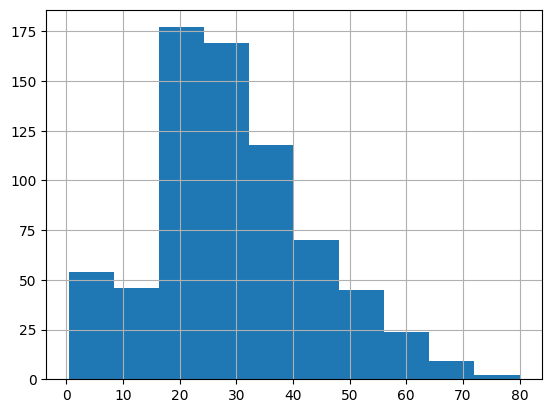

In [44]:
titanic['Age'].hist()
plt.show()

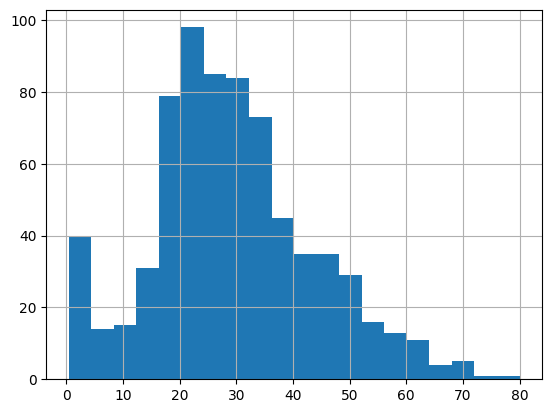

In [45]:
titanic['Age'].hist(bins=20)
plt.show()

<Axes: >

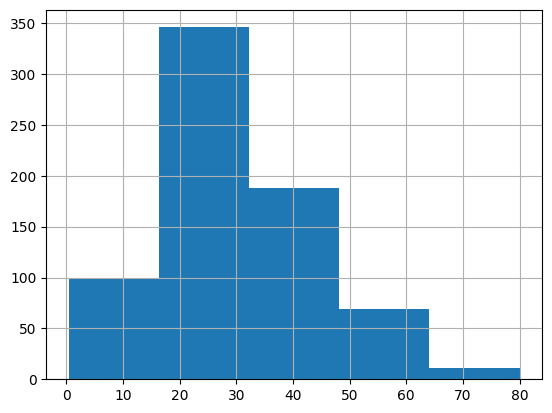

In [46]:
titanic['Age'].hist(bins=5)

### Bar plots

In [47]:
gender_count = titanic.groupby('Sex')['Age'].count()
gender_count

Sex
female    261
male      453
Name: Age, dtype: int64

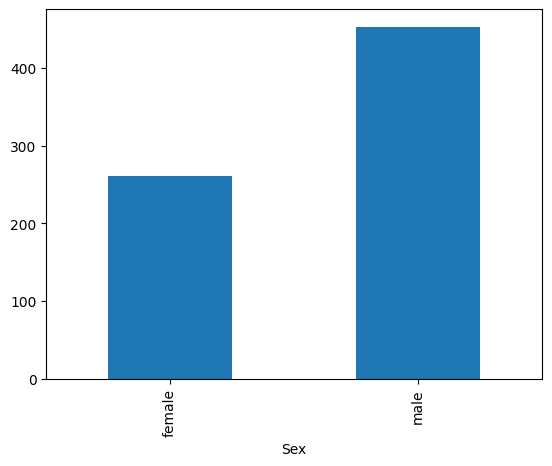

In [48]:
gender_count.plot(kind= 'bar')
plt.show()

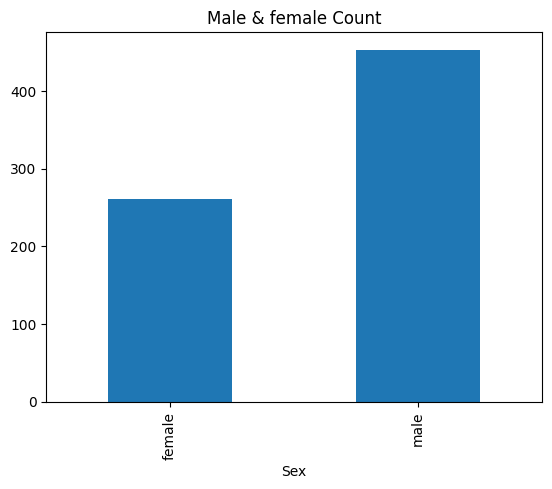

In [49]:
gender_count.plot(kind= 'bar', title= 'Male & female Count')
plt.show()

### Line plots

In [50]:
ten_ages = titanic.Age.iloc[7:15]
ten_ages

7      2.0
8     27.0
9     14.0
10     4.0
11    58.0
12    20.0
13    39.0
14    14.0
Name: Age, dtype: float64

<Axes: >

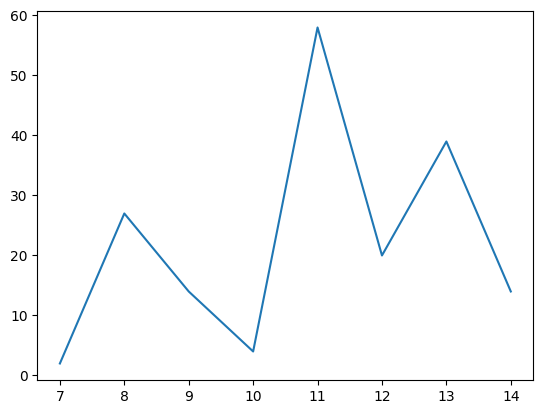

In [51]:
ten_ages.plot(x = ten_ages.index, y= ten_ages.values , kind= 'line') # < -- rotating x_labe

<Axes: >

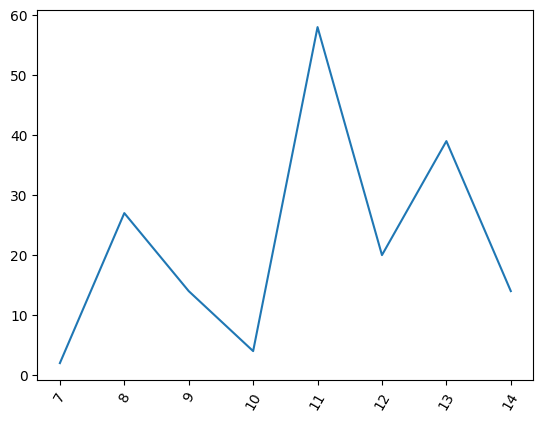

In [52]:
ten_ages.plot(x = ten_ages.index, y= ten_ages.values , kind= 'line', rot= 60)

### Scatter Plots

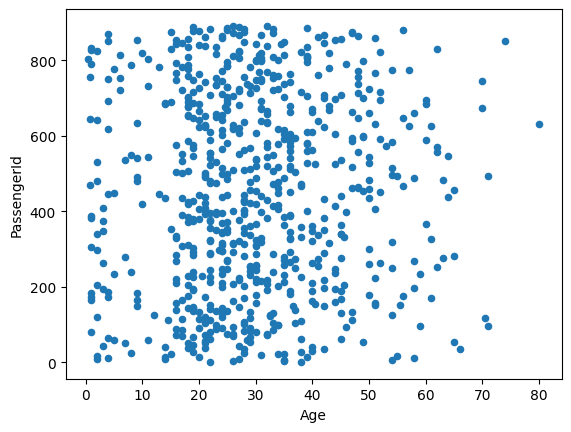

In [53]:
titanic.plot(x = 'Age', y= 'PassengerId' , kind= 'scatter')
plt.show()

### Layering plots

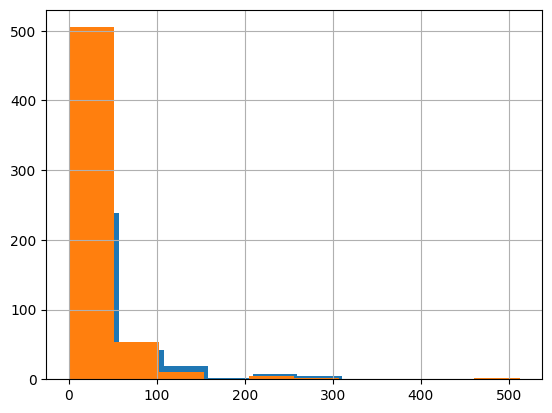

In [54]:
titanic[ titanic['Sex'] ==  "female"]['Fare'].hist() # < -- Blue Female
titanic[ titanic['Sex'] ==  "male"]['Fare'].hist() # <-- orange male
plt.show()

#### Add a legend

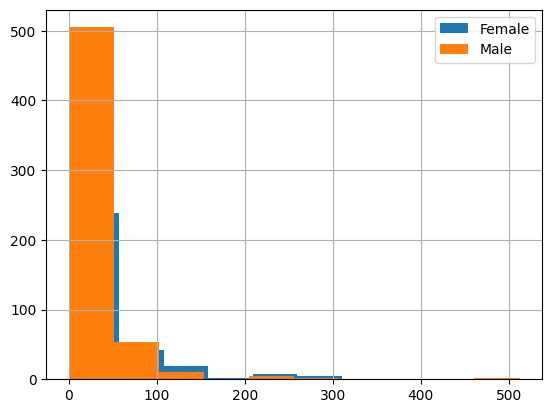

In [55]:
titanic[ titanic['Sex'] ==  "female"]['Fare'].hist()
titanic[ titanic['Sex'] ==  "male"]['Fare'].hist() 
plt.legend(['Female', 'Male']) #adding legend to make it more clear
plt.show()

#### transparency

<Axes: >

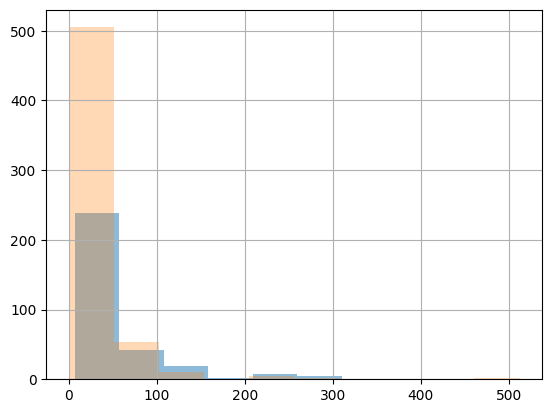

In [56]:
titanic[titanic['Sex'] == 'female']['Fare'].hist(alpha= 0.5) #<-- Blue
titanic[titanic['Sex'] == 'male']['Fare'].hist(alpha= 0.3)#<-- Orange

## Missing Values

In [57]:
titanic.shape

(891, 12)

In [58]:
titanic.isna().head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


In [59]:
titanic.isna().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool

In [60]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### ploting missing values

<Axes: >

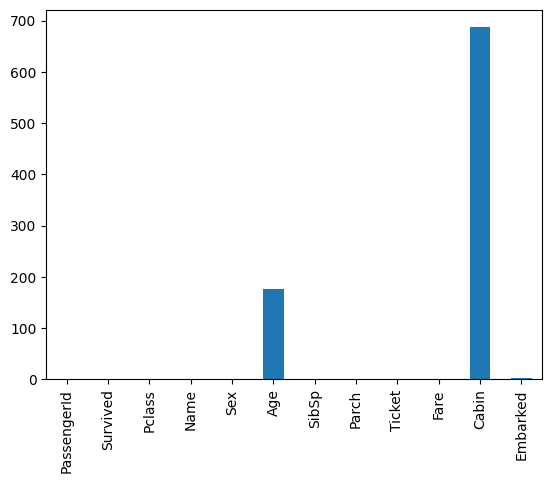

In [61]:
titanic.isna().sum().plot(kind='bar')

#### Removing missing values

In [62]:
titanic.dropna().head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [63]:
titanic.dropna().shape #<--method1

(183, 12)

In [64]:
titanic.fillna(0).shape #<--method2

(891, 12)

## Creating DataFrame

### list of Dictionaries - by row

In [65]:
list_of_dictionary = [
    {'name':'Ginger',
     'breed': 'lusi',
     'height_cm': 22,
     'weight_kgs':10 ,
     'date_of_birth':"2020-02-14"},
    
    { 'name': 'Scout',
     'breed': 'Dalmatian',
     'height_cm': 59,
     'weight_kgs':35 ,
     'date_of_birth':"2019-05-09"}
]

In [66]:
dogs = pd.DataFrame(list_of_dictionary)

In [67]:
dogs

,name,breed,height_cm,weight_kgs,date_of_birth
0,Ginger,lusi,22,10,2020-02-14
1,Scout,Dalmatian,59,35,2019-05-09


#### Dictionary pf list -by column

In [68]:
dict_of_list = {
    'name': ['lusi', 'Scout'],
    'breed': ['Desi', 'farmi'],
    'weight_kg': [22,20]
}

In [69]:
dogs1 = pd.DataFrame(dict_of_list)

In [70]:
dogs1

,name,breed,weight_kg
0,lusi,Desi,22
1,Scout,farmi,20


## Reading & writing CSVs

#### CSV to DataFrame

In [71]:
dogs = pd.read_csv('./dataset/dogs.csv')
dogs

,Name,Breed,Color,Height(cm),Weight(kg),Date of Birth
0,Bella,Labrador,Brown,56,25,2013-07-01
1,Charlie,Poodle,Black,43,23,2016-09-16
2,Lucy,Chow,Brown,46,22,2014-08-25
3,Cooper,Schnauzer,Gray,49,17,2011-12-11
4,Max,Labrador,Black,59,29,2017-01-20
5,Stella,Chihuahua,Tan,18,2,2015-04-20
6,Bernie,St. Bernard,White,77,74,2018-02-2


In [72]:
dogs['new_column'] = True

In [73]:
dogs

,Name,Breed,Color,Height(cm),Weight(kg),Date of Birth,new_column
0,Bella,Labrador,Brown,56,25,2013-07-01,True
1,Charlie,Poodle,Black,43,23,2016-09-16,True
2,Lucy,Chow,Brown,46,22,2014-08-25,True
3,Cooper,Schnauzer,Gray,49,17,2011-12-11,True
4,Max,Labrador,Black,59,29,2017-01-20,True
5,Stella,Chihuahua,Tan,18,2,2015-04-20,True
6,Bernie,St. Bernard,White,77,74,2018-02-2,True


In [74]:
dogs.to_csv('new_dogs.csv')